# DiT vs GPT — Even Parity Rule Learning

Compare DiT-nano/mini vs GPT-nano/mini on even-parity learning at matched architectures and dataset sizes.

**Architecture pairs (identical depth/heads/dim):**
- DiT-nano ↔ GPT-nano : 3L 6H 384D
- DiT-mini ↔ GPT-mini : 6L 6H 384D

**Matching N values:**
- nano: N=4096
- mini: N=4096, 8192, 16384

**Figures produced:**
1. `trajectory_*` — per-G loss / valid / mem / innovation curves (log step)
2. `speed_summary` — bar chart: steps-to-80%-valid
3. `final_heatmap` — annotated grid of final valid & mem
4. `compact_overview` — all (pair, N) rows in one figure
5. `timeheatmap` — heatmap: x=log-step, y=G, color=metric

In [1]:
import sys
sys.path.insert(0, '..')

import os
import csv
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────
SAVEROOT  = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
OUTDIR    = "../figures/dit_gpt_comparison"
SAVE_FIGS = True   # set False to only display inline

G_VALUES  = [2, 3, 4, 6, 9, 12, 18, 36]
THRESHOLD = 0.80   # valid_acc threshold for 'learned'

os.makedirs(OUTDIR, exist_ok=True)

In [3]:
# ── Data loading ───────────────────────────────────────────────────────────

def load_dit_parity(N, G, prefix="DiT_mini"):
    exp = f"{prefix}_parity_N{N}_D36_G{G}_even"
    d   = os.path.join(SAVEROOT, exp)
    if not os.path.isdir(d):
        return None
    loss_path = os.path.join(d, "loss_traj.pkl")
    if os.path.exists(loss_path):
        with open(loss_path, "rb") as f:
            lt = pickle.load(f)
        lt = np.array(lt, dtype=np.float32)
        stride = max(1, len(lt) // 2000)
        loss_steps = np.arange(1, len(lt)+1)[::stride]
        loss_vals  = lt[::stride]
    else:
        loss_steps = loss_vals = np.array([])
    eval_path = os.path.join(d, "mem_eval_stats.csv")
    if not os.path.exists(eval_path):
        eval_path = os.path.join(d, "pergroup_eval_stats.csv")
    if os.path.exists(eval_path):
        with open(eval_path) as f:
            rows = list(csv.DictReader(f))
        eval_steps = np.array([int(r["step"]) for r in rows])
        valid_acc  = np.array([float(r["sample_corr_acc"]) for r in rows])
        mem_ratio  = np.array([float(r.get("sample_mem_ratio", "nan")) for r in rows])
    else:
        eval_steps = valid_acc = mem_ratio = np.array([])
    return dict(loss_steps=loss_steps, loss_vals=loss_vals,
                eval_steps=eval_steps, valid_acc=valid_acc, mem_ratio=mem_ratio,
                max_steps=1_000_000)


def load_gpt_parity(N, G, prefix="GPT_mini"):
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    exp    = f"{prefix}_parity_N{N}_D36_G{G}_even"
    tb_dir = os.path.join(SAVEROOT, exp, "tensorboard")
    if not os.path.isdir(tb_dir):
        return None
    ea = EventAccumulator(tb_dir, size_guidance={"scalars": 0})
    ea.Reload()
    def get(tag):
        try:
            evs = ea.Scalars(tag)
            return np.array([e.step for e in evs]), np.array([e.value for e in evs])
        except:
            return np.array([]), np.array([])
    ls, lv = get("Training/Loss_Step")
    vs, vv = get("Eval/Sample_Accuracy")
    ms, mv = get("Eval/Sample_Mem_Ratio")
    n = min(len(vs), len(ms))
    return dict(loss_steps=ls, loss_vals=lv,
                eval_steps=vs[:n], valid_acc=vv[:n], mem_ratio=mv[:n],
                max_steps=100_000)


def ewm_smooth(vals, alpha=0.9):
    if len(vals) == 0: return vals
    out = np.empty_like(vals, dtype=float)
    out[0] = vals[0]
    for i in range(1, len(vals)):
        out[i] = alpha * out[i-1] + (1 - alpha) * vals[i]
    return out


def step_to_threshold(steps, vals, thr=THRESHOLD):
    if len(steps) == 0: return None
    idx = np.where(vals >= thr)[0]
    return int(steps[idx[0]]) if len(idx) > 0 else None

print('Data loaders ready.')

Data loaders ready.


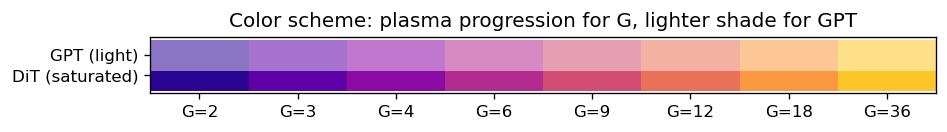

In [4]:
# ── Color scheme ───────────────────────────────────────────────────────────
_G_CMAP      = plt.cm.plasma
_G_POSITIONS = np.linspace(0.05, 0.88, len(G_VALUES))
G_COLORS     = {G: _G_CMAP(p) for G, p in zip(G_VALUES, _G_POSITIONS)}

def _gpt_color(rgba, mix=0.45):
    r, g, b, a = rgba
    return (r + (1-r)*mix, g + (1-g)*mix, b + (1-b)*mix, a)

# Preview color scheme
fig, ax = plt.subplots(1, 1, figsize=(8, 1.2))
for i, G in enumerate(G_VALUES):
    ax.barh(0, 1, left=i, color=G_COLORS[G], label=f'G={G}')
    ax.barh(0.5, 1, left=i, color=_gpt_color(G_COLORS[G]))
ax.set_xlim(0, len(G_VALUES))
ax.set_yticks([0, 0.5]); ax.set_yticklabels(['DiT (saturated)', 'GPT (light)'])
ax.set_xticks(np.arange(len(G_VALUES)) + 0.5)
ax.set_xticklabels([f'G={G}' for G in G_VALUES])
ax.set_title('Color scheme: plasma progression for G, lighter shade for GPT')
plt.tight_layout(); plt.show()

## Figure 1: Trajectory Grid
Loss / Valid acc / Mem ratio / Innovation on log-step scale, one row per G value.

In [5]:
def plot_trajectory_grid(N, dit_prefix="DiT_mini", gpt_prefix="GPT_mini",
                         dit_color="steelblue", gpt_color="tomato",
                         dit_label="DiT-mini", gpt_label="GPT-mini",
                         save=True):
    n_g = len(G_VALUES)
    fig, axes = plt.subplots(n_g, 4, figsize=(19, 2.8 * n_g), sharex=False)
    fig.suptitle(f"{dit_label} vs {gpt_label}  |  N={N:,}  |  Even Parity D=36",
                 fontsize=13, fontweight="bold")
    col_titles = ["Loss", "Valid acc (sample)", "Mem ratio", "Innovation (valid − mem)"]
    for ci, ct in enumerate(col_titles):
        axes[0, ci].set_title(ct, fontsize=11)
    for ri, G in enumerate(G_VALUES):
        dit = load_dit_parity(N, G, prefix=dit_prefix)
        gpt = load_gpt_parity(N, G, prefix=gpt_prefix)
        for ci, metric in enumerate(["loss", "valid", "mem", "innov"]):
            ax = axes[ri, ci]
            for data, color, label in [(dit, dit_color, dit_label), (gpt, gpt_color, gpt_label)]:
                if data is None: continue
                if metric == "loss" and len(data["loss_steps"]) > 0:
                    sm = ewm_smooth(data["loss_vals"], alpha=0.95 if color==dit_color else 0.9)
                    ax.plot(data["loss_steps"], data["loss_vals"], color=color, alpha=0.15, lw=0.7)
                    ax.plot(data["loss_steps"], sm, color=color, lw=1.6, label=label)
                elif metric == "valid" and len(data["eval_steps"]) > 0:
                    ax.plot(data["eval_steps"], data["valid_acc"], color=color, lw=1.8,
                            marker=".", markersize=2, label=label)
                elif metric == "mem" and len(data["eval_steps"]) > 0:
                    ax.plot(data["eval_steps"], data["mem_ratio"], color=color, lw=1.8,
                            marker=".", markersize=2, label=label)
                elif metric == "innov" and len(data["eval_steps"]) > 0:
                    innov = np.clip(data["valid_acc"] - data["mem_ratio"], 0, 1)
                    ax.plot(data["eval_steps"], innov, color=color, lw=1.8,
                            marker=".", markersize=2, label=label)
            if metric == "innov":
                ax.set_ylim(-0.02, 1.05)
                rb = 0.5 ** (36 / G)
                ax.axhline(rb, color="gray", lw=1.2, ls="--", alpha=0.8, label=f"random ({rb:.3f})")
                if ri == 0: ax.legend(fontsize=7, loc="upper left")
            ax.set_xscale("log"); ax.grid(alpha=0.2)
            if ci == 0: ax.set_ylabel(f"G={G}", fontsize=9)
            if ri == n_g-1: ax.set_xlabel("Step", fontsize=9)
            if ri == 0 and ci == 0: ax.legend(fontsize=8)
    plt.tight_layout()
    if save and SAVE_FIGS:
        pair_tag = f"{dit_label.replace('-','').replace(' ','_')}_vs_{gpt_label.replace('-','').replace(' ','_')}"
        out = os.path.join(OUTDIR, f"trajectory_{pair_tag}_N{N}.png")
        plt.savefig(out, dpi=130, bbox_inches="tight")
        out_pdf = out.replace('.png', '.pdf')
        plt.savefig(out_pdf, bbox_inches="tight")
        print(f"Saved → {out}")
    plt.show()

Saved → ../figures/dit_gpt_comparison/trajectory_DiTnano_vs_GPTnano_N4096.png


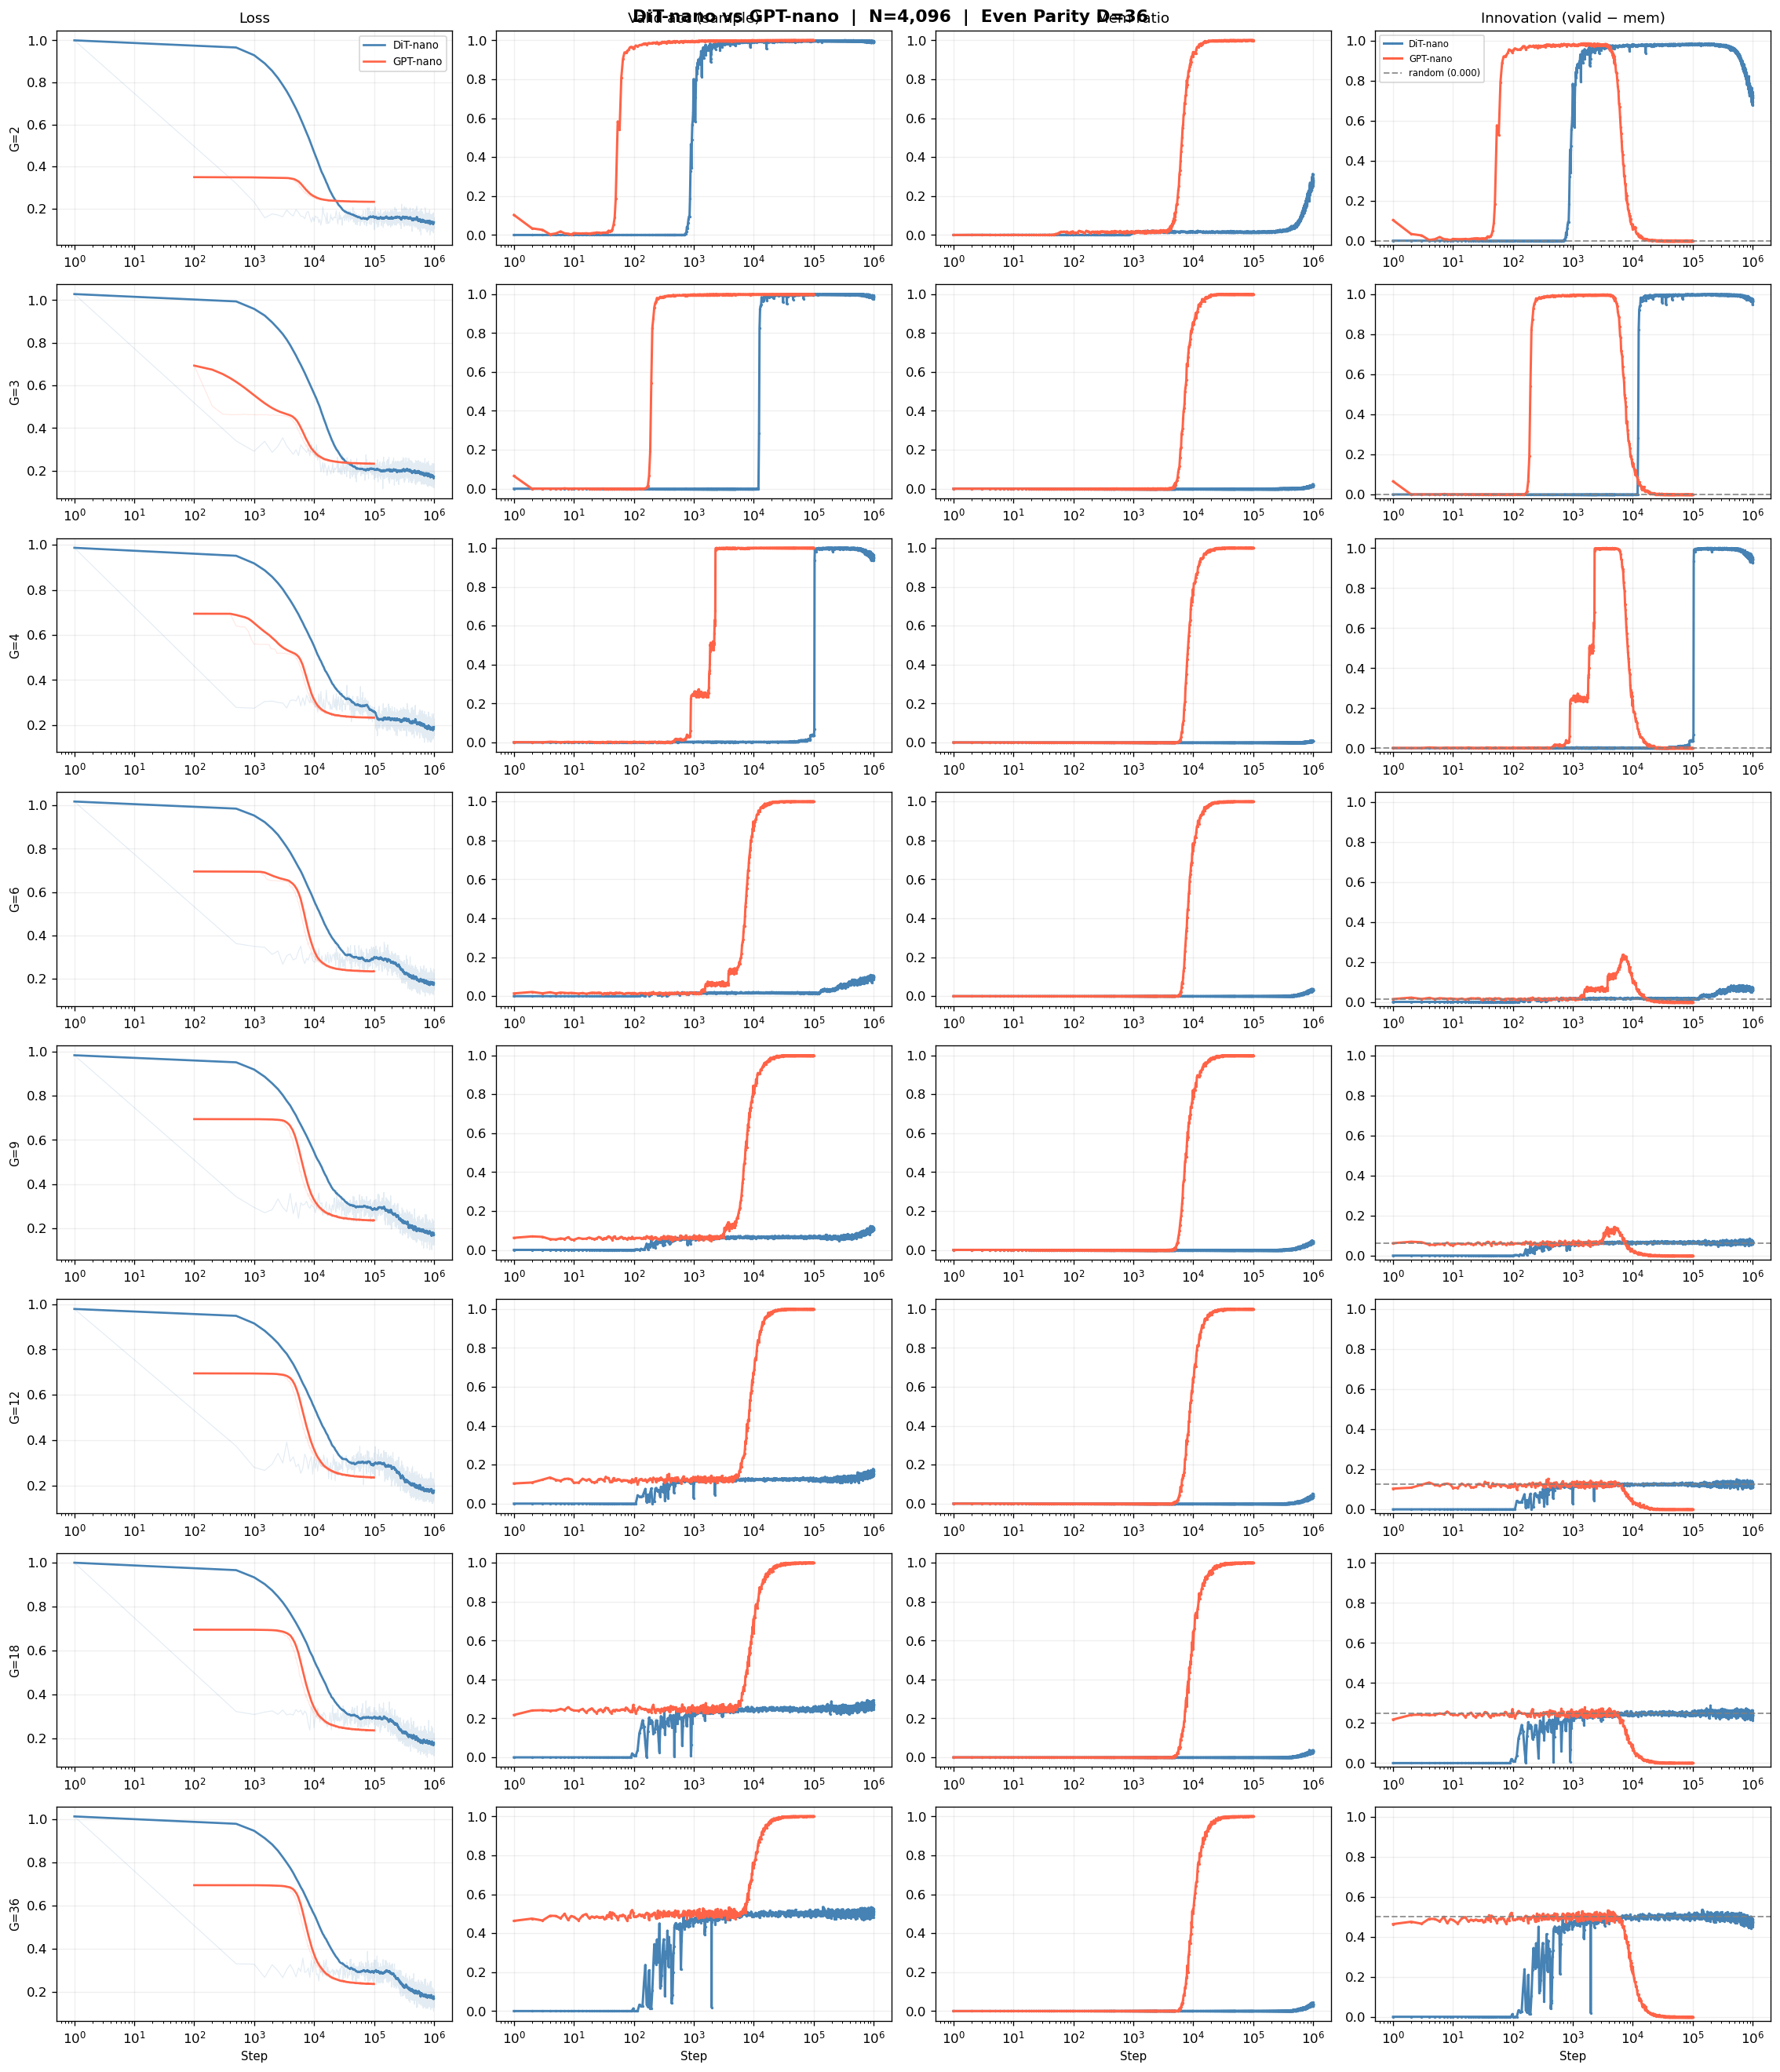

In [6]:
# DiT-nano vs GPT-nano
plot_trajectory_grid(4096, dit_prefix="DiT_nano", gpt_prefix="GPT_nano",
                     dit_label="DiT-nano", gpt_label="GPT-nano")

Saved → ../figures/dit_gpt_comparison/trajectory_DiTmini_vs_GPTmini_N4096.png


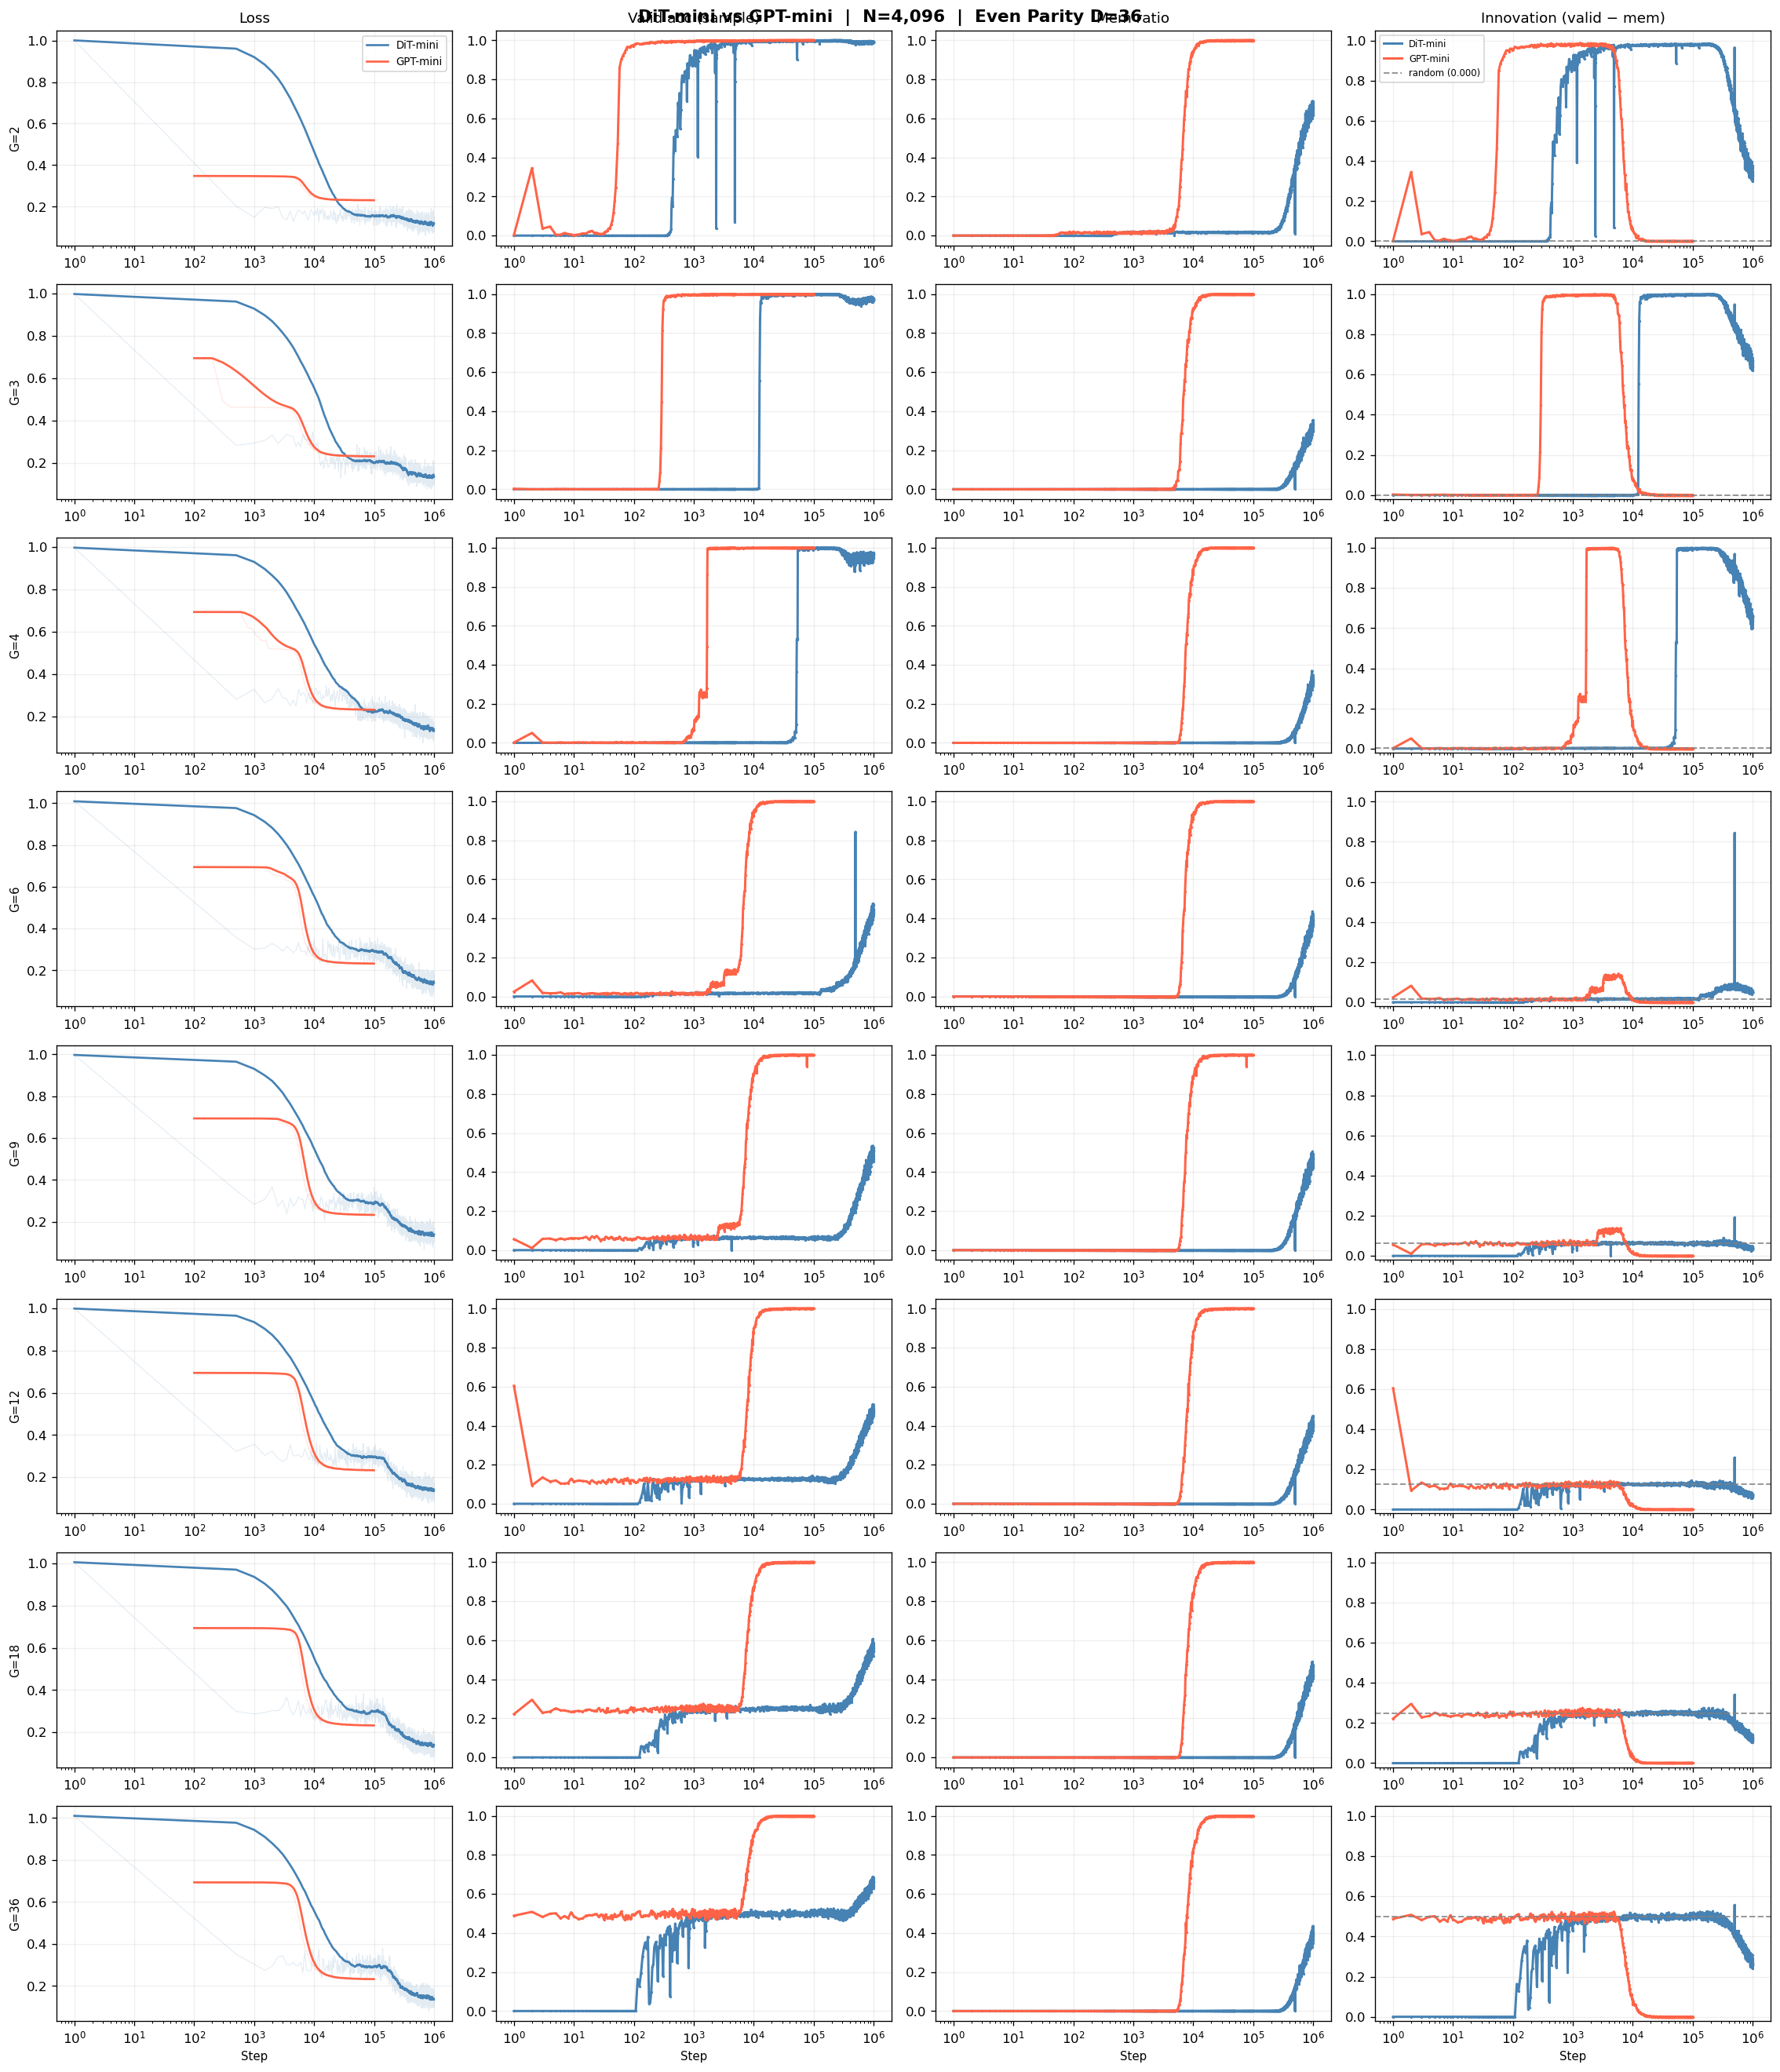

Saved → ../figures/dit_gpt_comparison/trajectory_DiTmini_vs_GPTmini_N8192.png


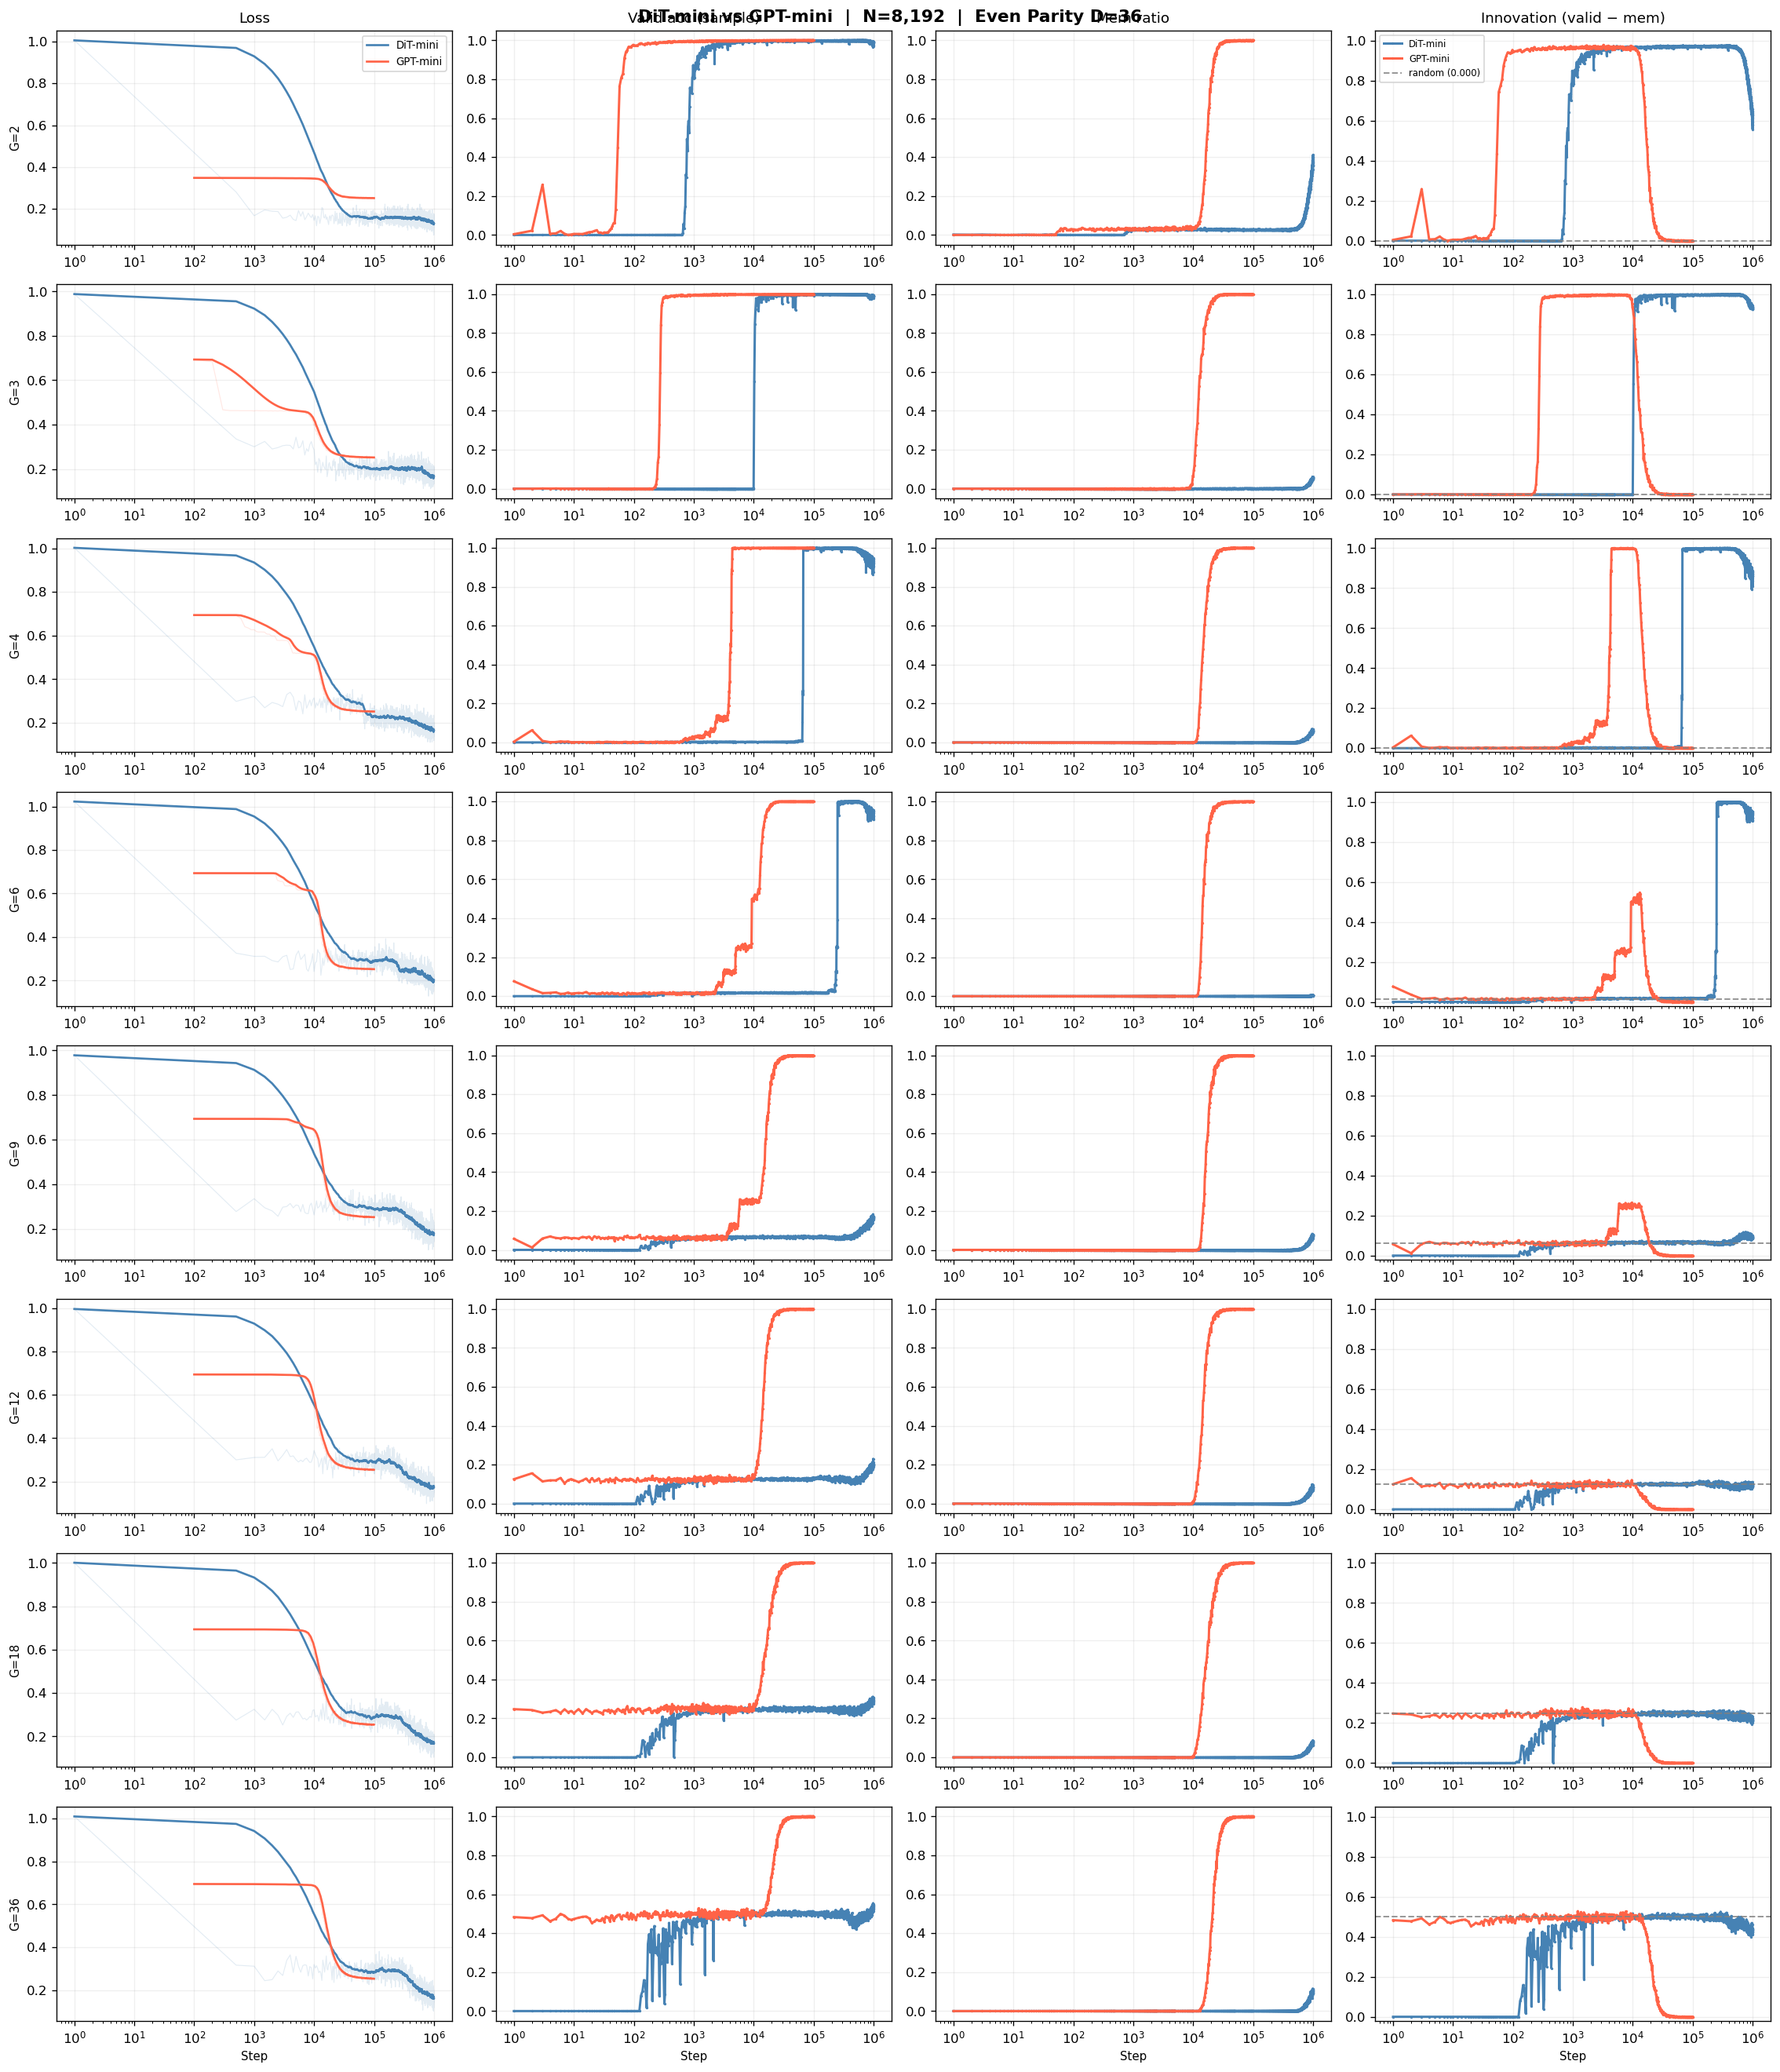

Saved → ../figures/dit_gpt_comparison/trajectory_DiTmini_vs_GPTmini_N16384.png


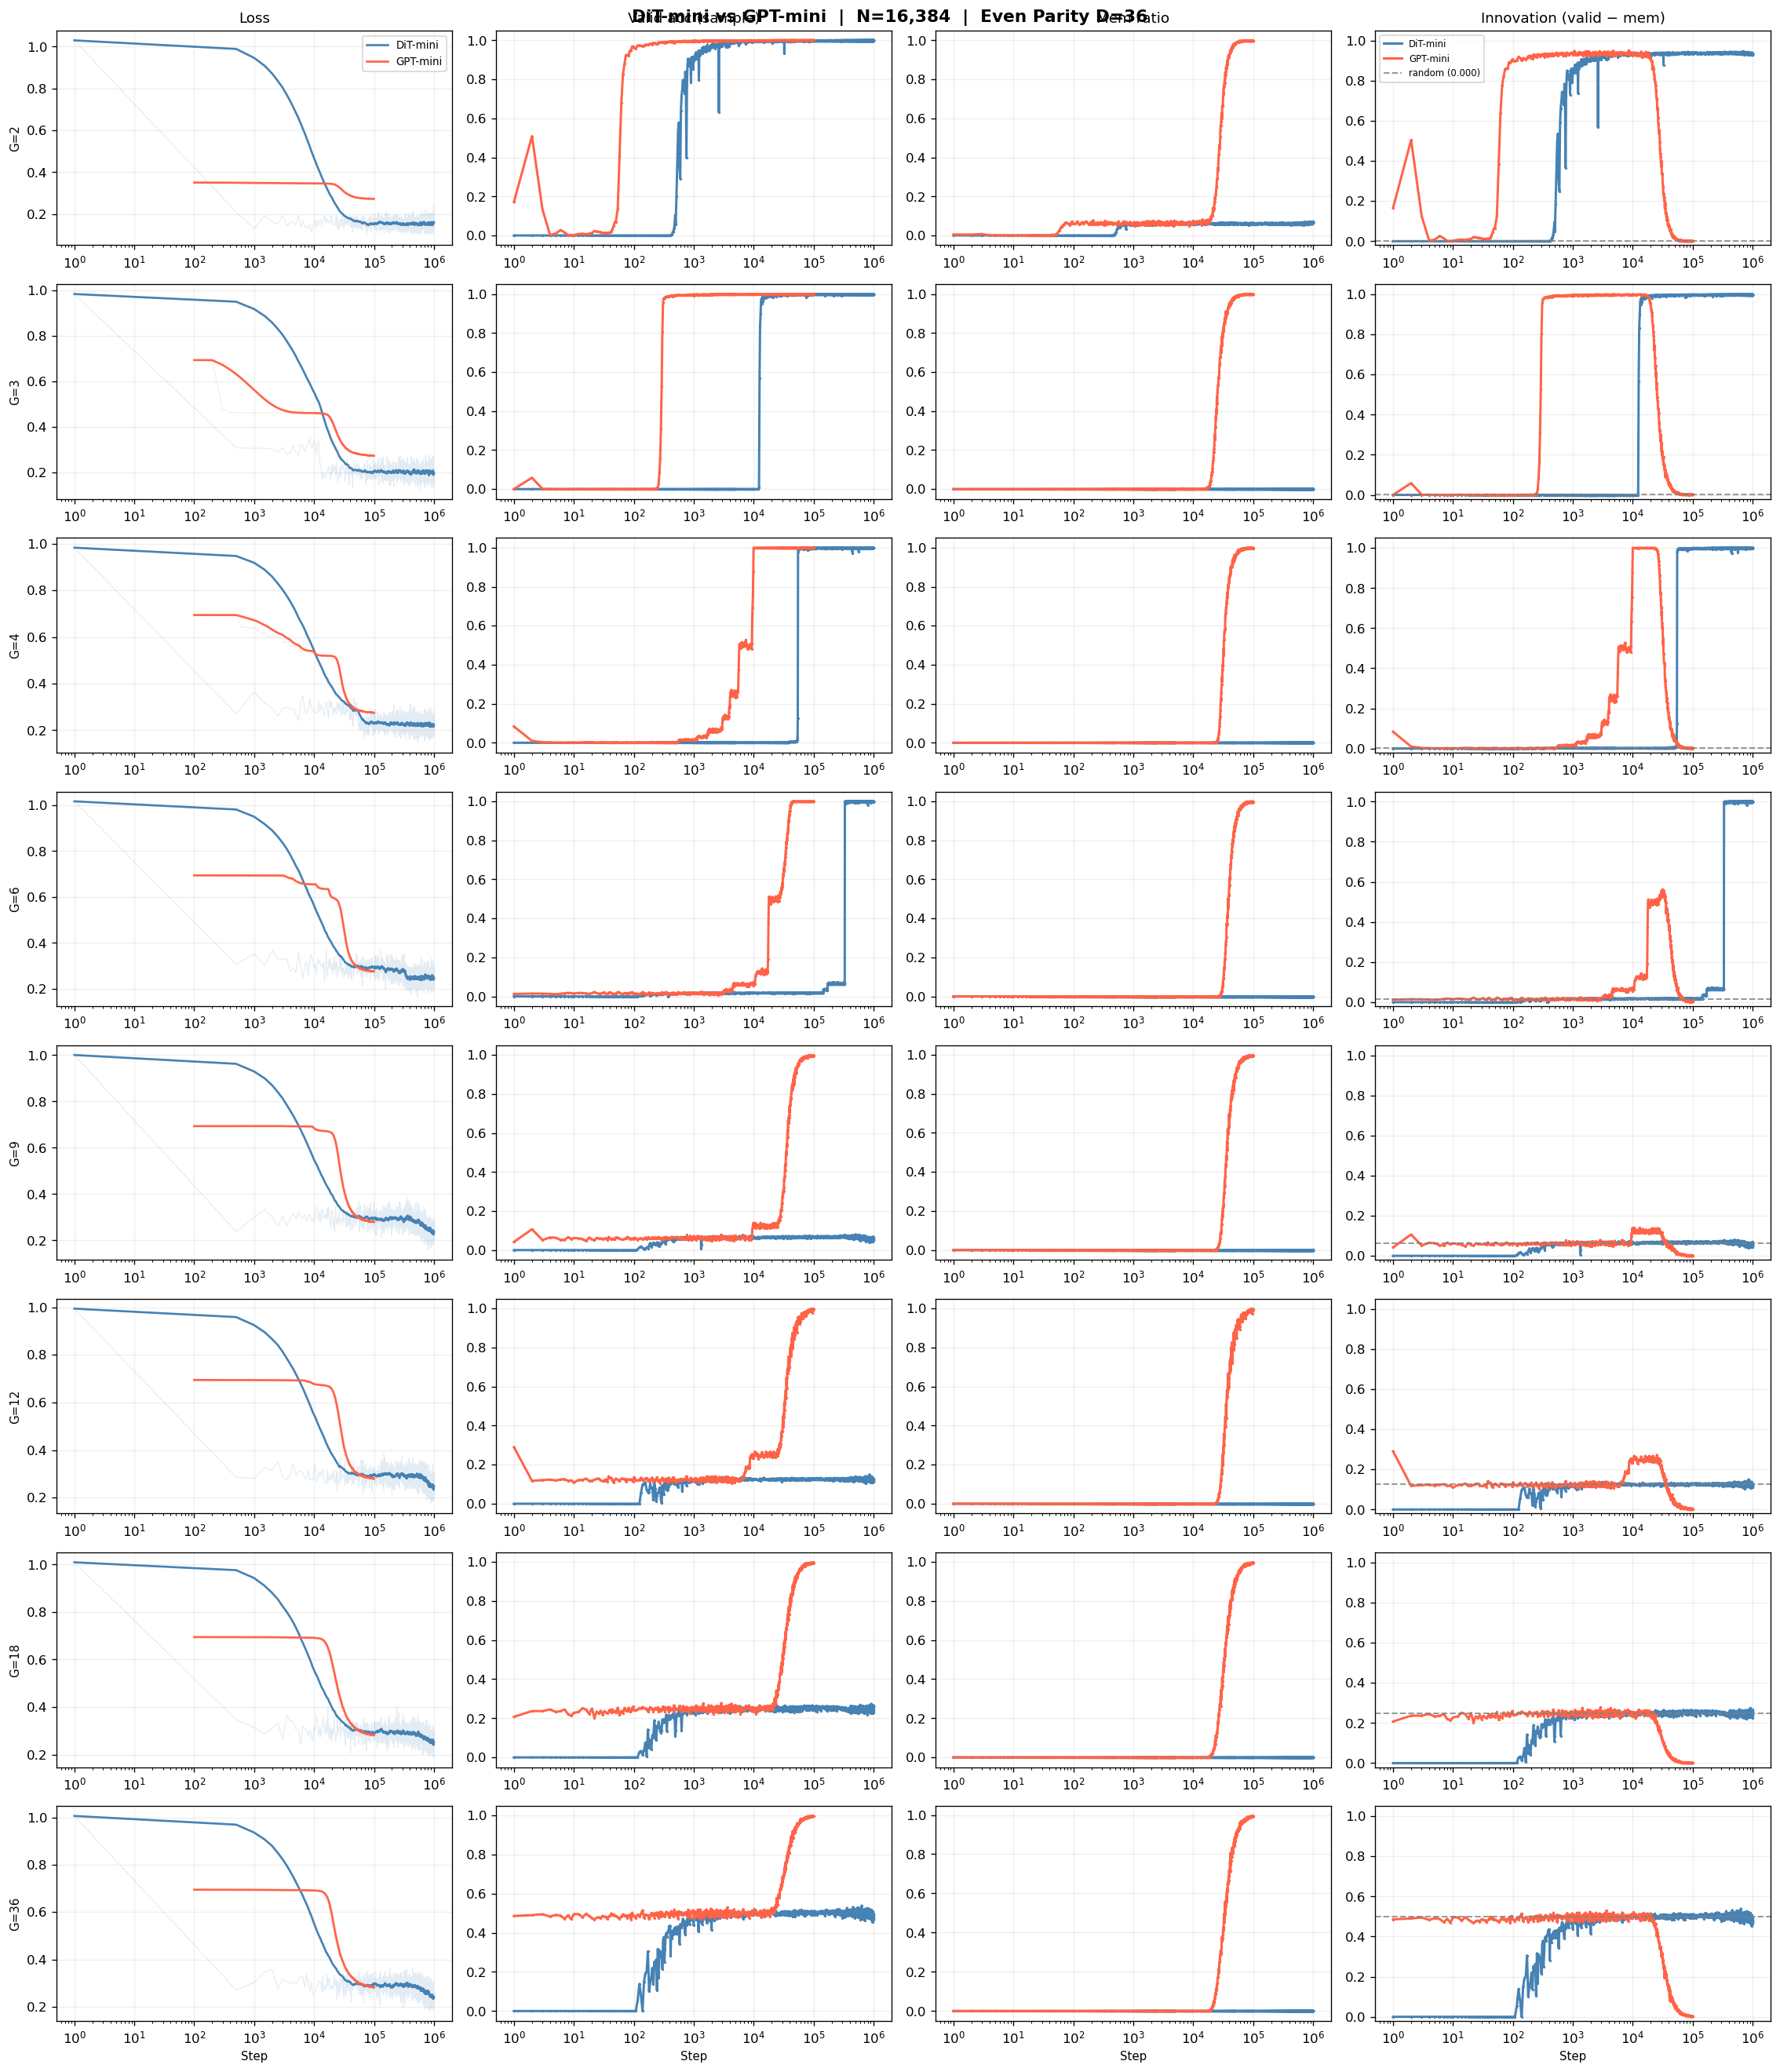

In [7]:
# DiT-mini vs GPT-mini — N=4096, 8192, 16384
for N in [4096, 8192, 16384]:
    plot_trajectory_grid(N, dit_prefix="DiT_mini", gpt_prefix="GPT_mini",
                         dit_label="DiT-mini", gpt_label="GPT-mini")

## Figure 2: Speed Summary
How many steps does each model need to first reach 80% valid accuracy?

Saved → ../figures/dit_gpt_comparison/speed_summary.png


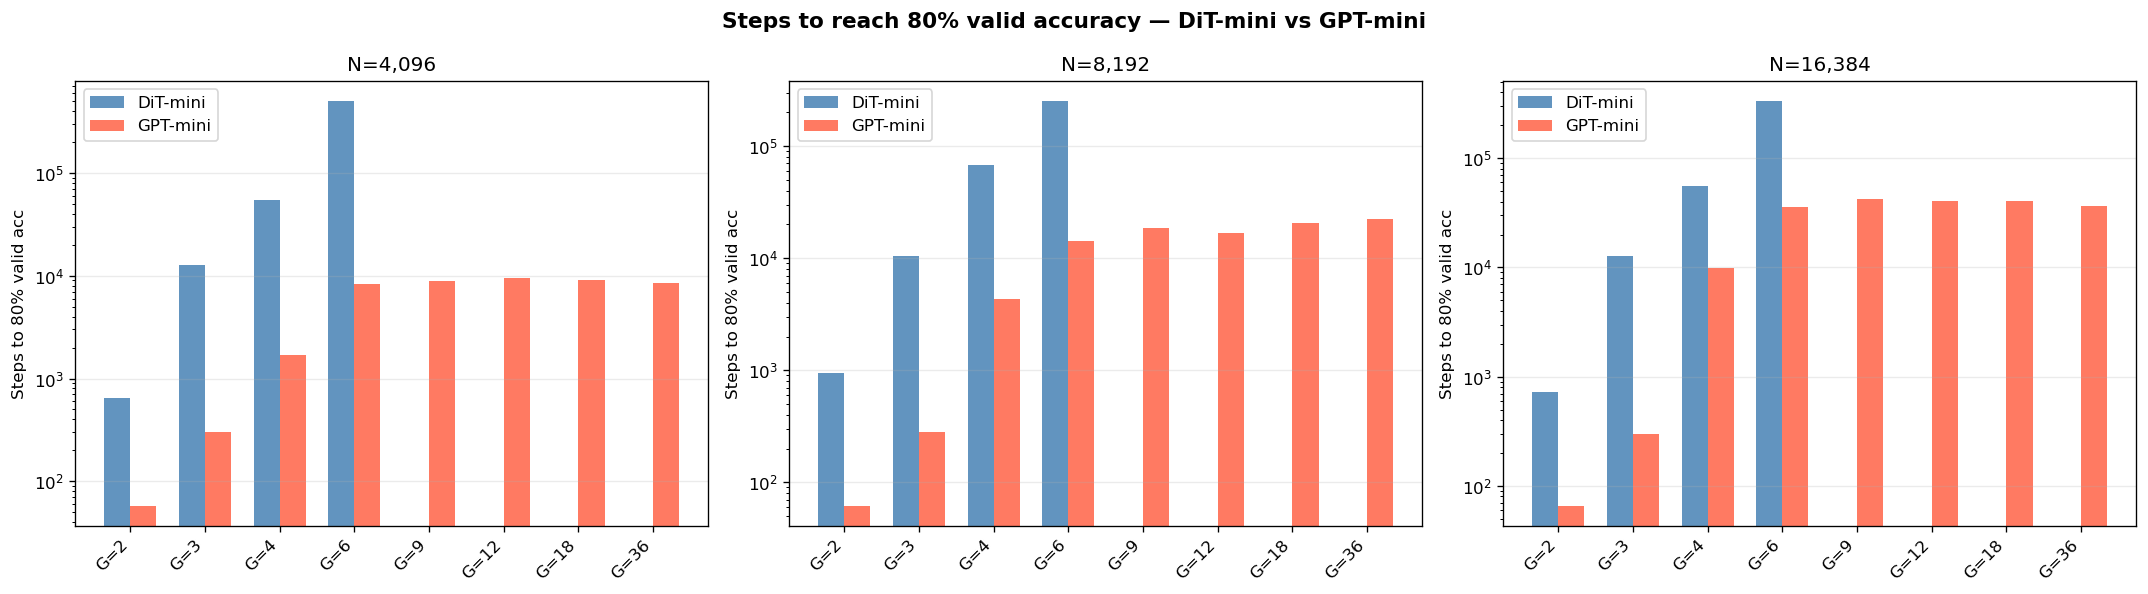

Saved → ../figures/dit_gpt_comparison/speed_summary.png


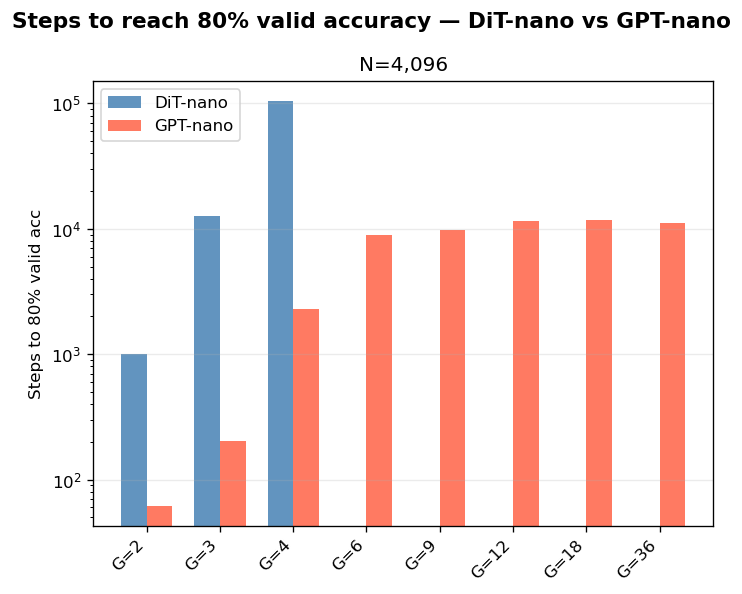

In [8]:
def plot_speed_summary(dit_prefix="DiT_mini", gpt_prefix="GPT_mini",
                       n_list=None, dit_label="DiT-mini", gpt_label="GPT-mini",
                       save=True):
    if n_list is None: n_list = [4096, 8192, 16384]
    fig, axes = plt.subplots(1, len(n_list), figsize=(6*len(n_list), 5))
    if len(n_list) == 1: axes = [axes]
    fig.suptitle(f"Steps to reach {THRESHOLD*100:.0f}% valid accuracy — {dit_label} vs {gpt_label}",
                 fontsize=13, fontweight="bold")
    for ai, N in enumerate(n_list):
        ax = axes[ai]
        dit_steps, gpt_steps = [], []
        for G in G_VALUES:
            dit = load_dit_parity(N, G, prefix=dit_prefix)
            gpt = load_gpt_parity(N, G, prefix=gpt_prefix)
            dit_steps.append(step_to_threshold(dit["eval_steps"], dit["valid_acc"]) if dit else None)
            gpt_steps.append(step_to_threshold(gpt["eval_steps"], gpt["valid_acc"]) if gpt else None)
        x = np.arange(len(G_VALUES)); w = 0.35
        ax.bar(x-w/2, [s or np.nan for s in dit_steps], w, label=dit_label, color="steelblue", alpha=0.85)
        ax.bar(x+w/2, [s or np.nan for s in gpt_steps], w, label=gpt_label, color="tomato",    alpha=0.85)
        ax.set_yscale("log")
        ax.set_xticks(x); ax.set_xticklabels([f"G={g}" for g in G_VALUES], rotation=45, ha="right")
        ax.set_title(f"N={N:,}"); ax.set_ylabel("Steps to 80% valid acc"); ax.legend(); ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    if save and SAVE_FIGS:
        out = os.path.join(OUTDIR, "speed_summary.png")
        plt.savefig(out, dpi=130, bbox_inches="tight")
        plt.savefig(out.replace('.png','.pdf'), bbox_inches="tight")
        print(f"Saved → {out}")
    plt.show()

plot_speed_summary()
plot_speed_summary(dit_prefix="DiT_nano", gpt_prefix="GPT_nano", n_list=[4096],
                   dit_label="DiT-nano", gpt_label="GPT-nano")

## Figure 3: Final Valid Acc & Mem Ratio Heatmap

Saved → ../figures/dit_gpt_comparison/final_heatmap.png


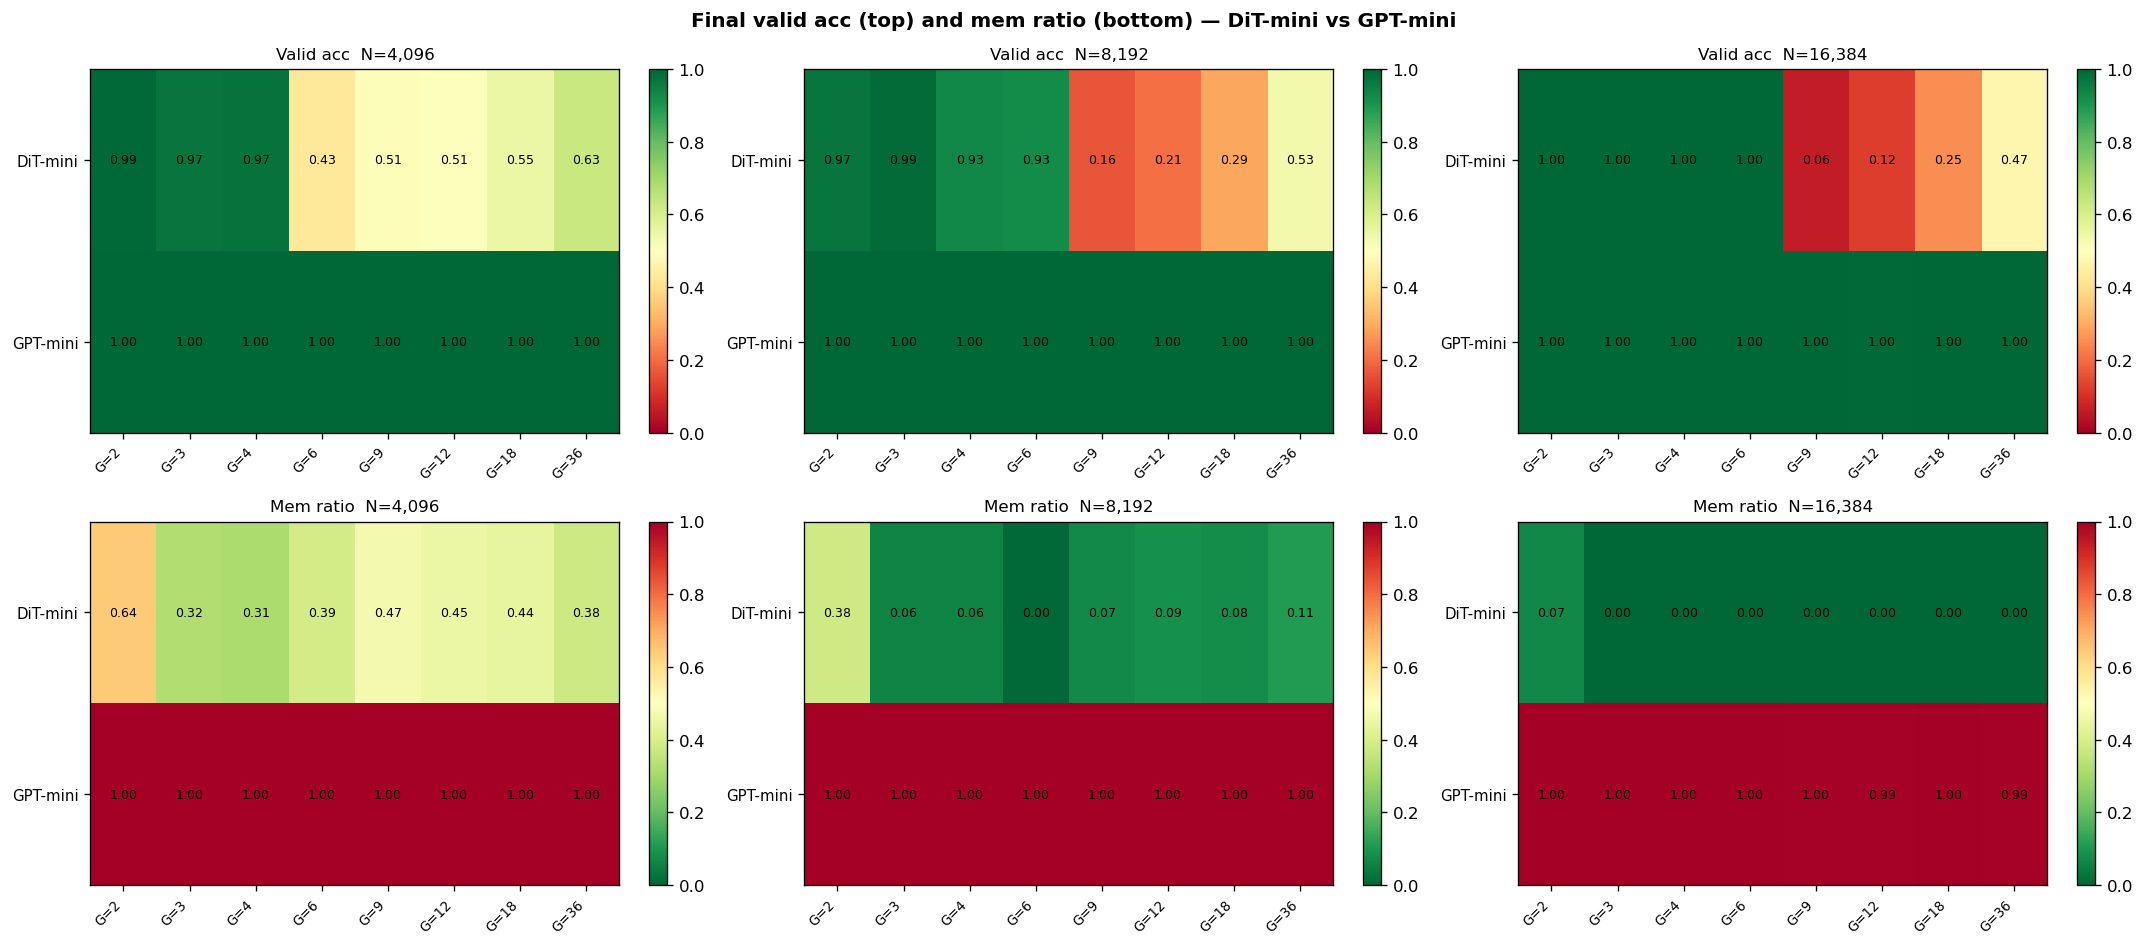

In [9]:
def plot_final_heatmap(dit_prefix="DiT_mini", gpt_prefix="GPT_mini",
                       n_list=None, dit_label="DiT-mini", gpt_label="GPT-mini",
                       save=True):
    if n_list is None: n_list = [4096, 8192, 16384]
    fig, axes = plt.subplots(2, len(n_list), figsize=(6*len(n_list), 8))
    if len(n_list) == 1: axes = axes.reshape(2, 1)
    fig.suptitle(f"Final valid acc (top) and mem ratio (bottom) — {dit_label} vs {gpt_label}",
                 fontsize=12, fontweight="bold")
    for ai, N in enumerate(n_list):
        dit_valid, gpt_valid, dit_mem, gpt_mem = [], [], [], []
        for G in G_VALUES:
            dit = load_dit_parity(N, G, prefix=dit_prefix)
            gpt = load_gpt_parity(N, G, prefix=gpt_prefix)
            dit_valid.append(dit["valid_acc"][-1] if dit and len(dit["valid_acc"]) else np.nan)
            gpt_valid.append(gpt["valid_acc"][-1] if gpt and len(gpt["valid_acc"]) else np.nan)
            dit_mem.append(dit["mem_ratio"][-1]   if dit and len(dit["mem_ratio"])  else np.nan)
            gpt_mem.append(gpt["mem_ratio"][-1]   if gpt and len(gpt["mem_ratio"])  else np.nan)
        for row, (data, label) in enumerate([
            (np.array([dit_valid, gpt_valid]), "Valid acc"),
            (np.array([dit_mem,   gpt_mem]),   "Mem ratio")]):
            ax = axes[row, ai]
            im = ax.imshow(data, aspect="auto", vmin=0, vmax=1,
                           cmap="RdYlGn" if row == 0 else "RdYlGn_r")
            ax.set_xticks(range(len(G_VALUES)))
            ax.set_xticklabels([f"G={g}" for g in G_VALUES], rotation=45, ha="right", fontsize=8)
            ax.set_yticks([0, 1]); ax.set_yticklabels([dit_label, gpt_label], fontsize=9)
            ax.set_title(f"{label}  N={N:,}", fontsize=10)
            plt.colorbar(im, ax=ax, fraction=0.046)
            for yi in range(2):
                for xi in range(len(G_VALUES)):
                    v = data[yi, xi]
                    if not np.isnan(v):
                        ax.text(xi, yi, f"{v:.2f}", ha="center", va="center", fontsize=7.5)
    plt.tight_layout()
    if save and SAVE_FIGS:
        out = os.path.join(OUTDIR, "final_heatmap.png")
        plt.savefig(out, dpi=130, bbox_inches="tight")
        plt.savefig(out.replace('.png','.pdf'), bbox_inches="tight")
        print(f"Saved → {out}")
    plt.show()

plot_final_heatmap()

## Figure 4: Compact Overview
All (pair, N) combinations in one figure. Color=G (plasma), solid=DiT, dashed=GPT.

Saved → ../figures/dit_gpt_comparison/compact_overview.png


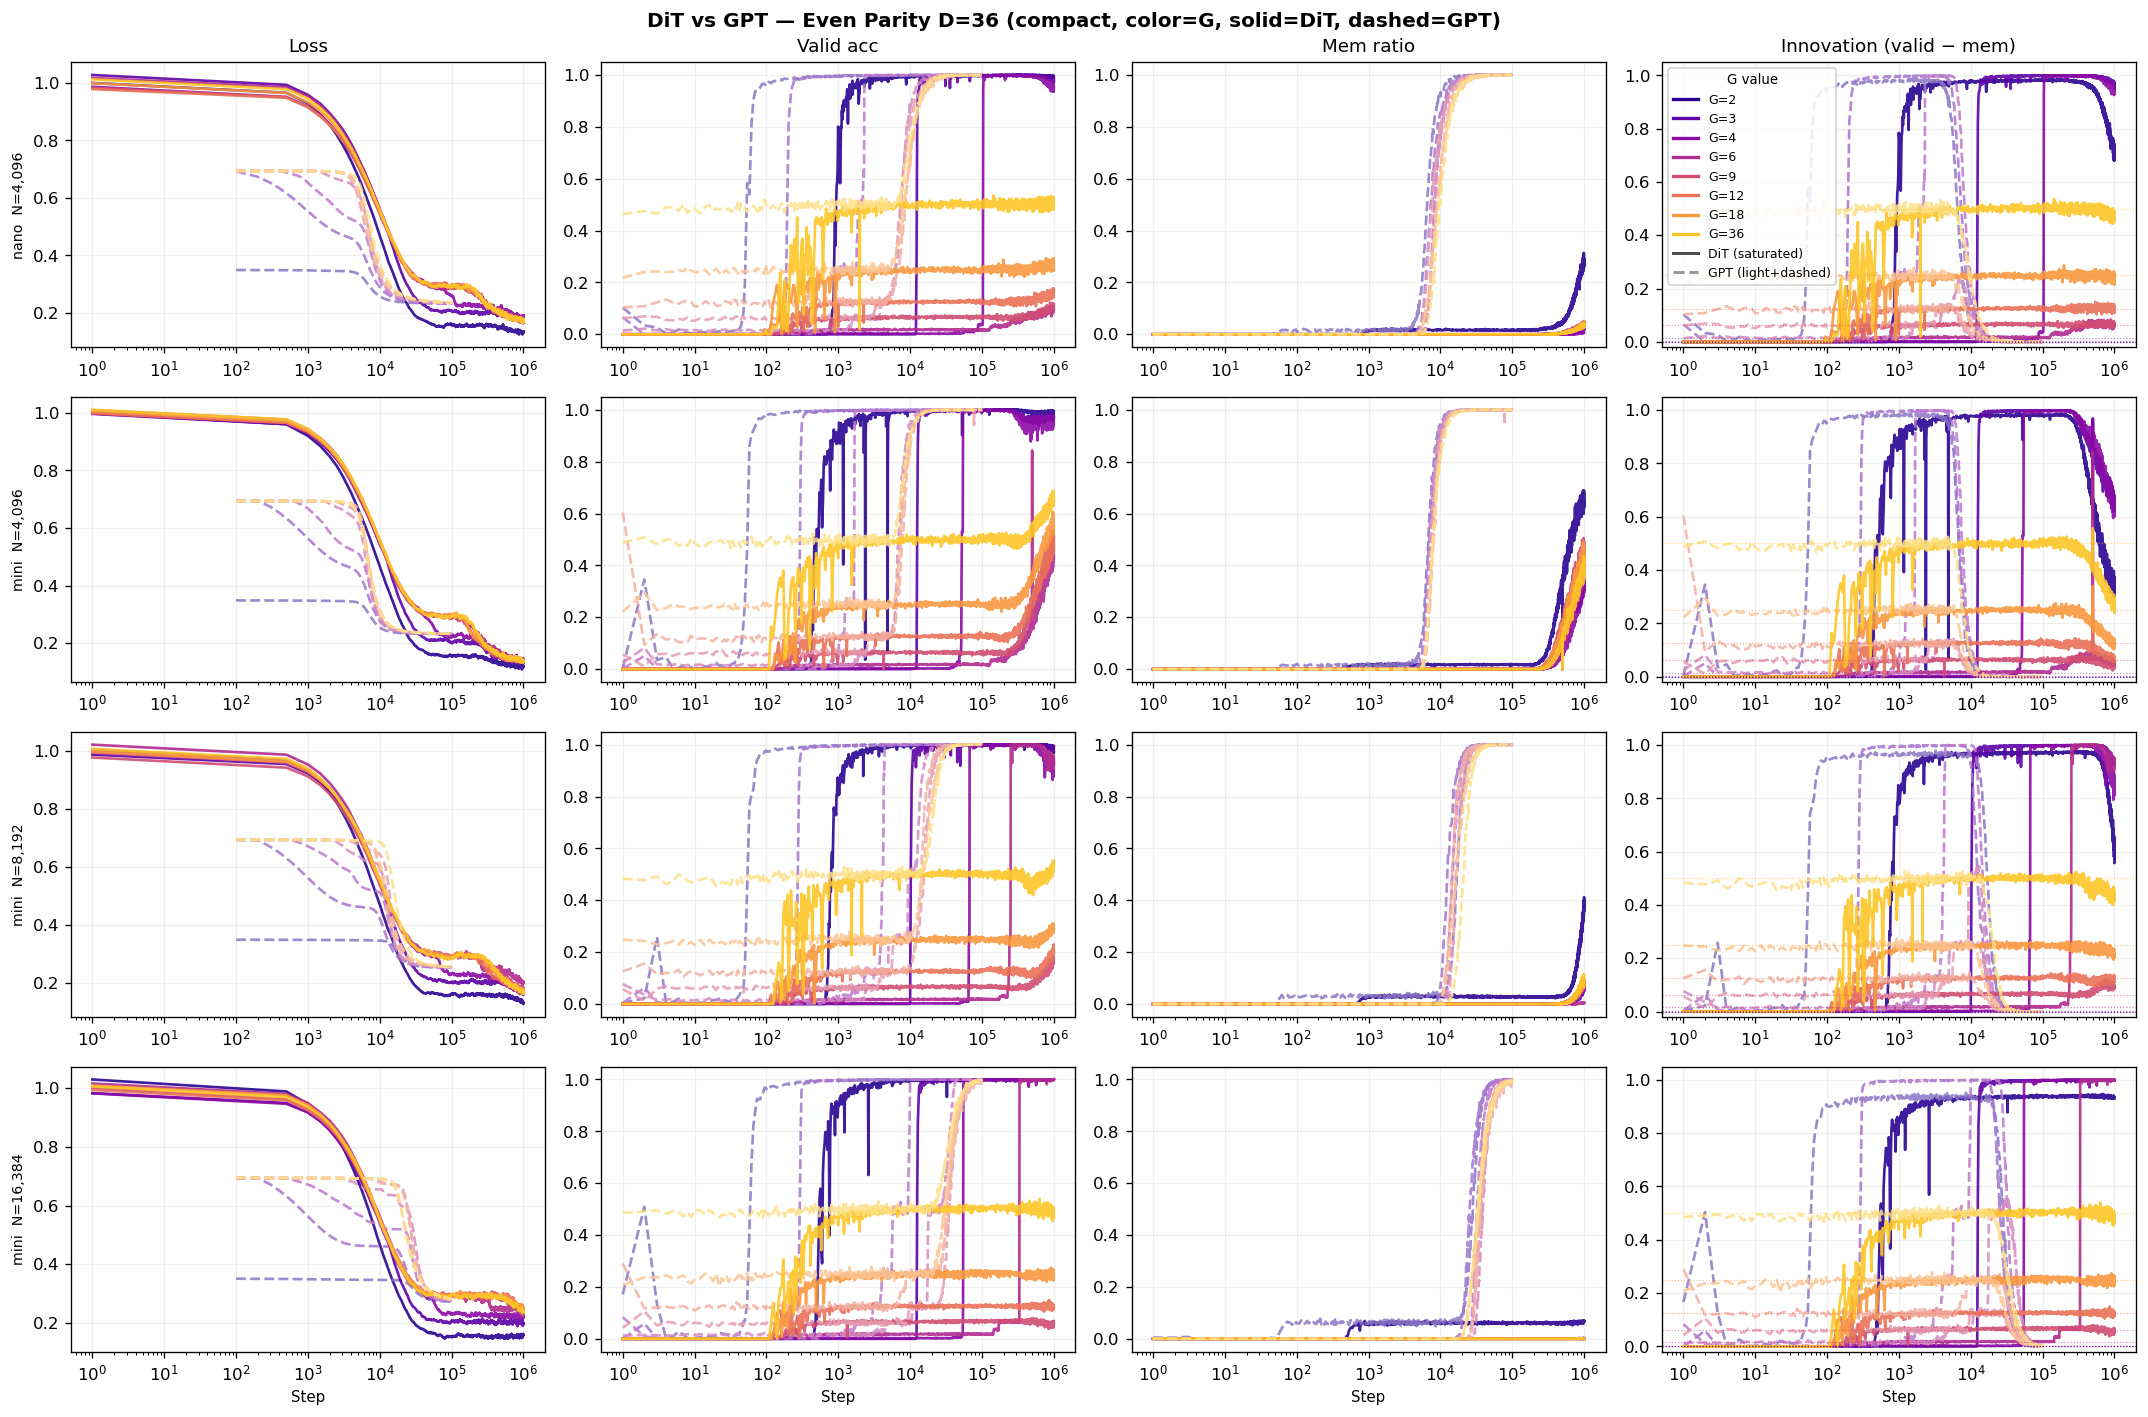

In [10]:
COMPACT_ROWS = [
    dict(dit_prefix="DiT_nano", gpt_prefix="GPT_nano", N=4096,
         dit_label="DiT-nano", gpt_label="GPT-nano", row_label="nano  N=4,096"),
    dict(dit_prefix="DiT_mini", gpt_prefix="GPT_mini", N=4096,
         dit_label="DiT-mini", gpt_label="GPT-mini", row_label="mini  N=4,096"),
    dict(dit_prefix="DiT_mini", gpt_prefix="GPT_mini", N=8192,
         dit_label="DiT-mini", gpt_label="GPT-mini", row_label="mini  N=8,192"),
    dict(dit_prefix="DiT_mini", gpt_prefix="GPT_mini", N=16384,
         dit_label="DiT-mini", gpt_label="GPT-mini", row_label="mini  N=16,384"),
]

def plot_compact(rows, outname="compact_overview.png", save=True):
    n_rows = len(rows)
    fig, axes = plt.subplots(n_rows, 4, figsize=(18, 3.0*n_rows), squeeze=False)
    col_titles = ["Loss", "Valid acc", "Mem ratio", "Innovation (valid − mem)"]
    for ci, ct in enumerate(col_titles):
        axes[0, ci].set_title(ct, fontsize=11)
    random_baseline = {G: 0.5**(36/G) for G in G_VALUES}
    for ri, row in enumerate(rows):
        for ci, metric in enumerate(["loss", "valid", "mem", "innov"]):
            ax = axes[ri, ci]
            for G in G_VALUES:
                col = G_COLORS[G]
                dit = load_dit_parity(row["N"], G, prefix=row["dit_prefix"])
                gpt = load_gpt_parity(row["N"], G, prefix=row["gpt_prefix"])
                def _get(d, m, is_dit):
                    if d is None: return None, None
                    if m=="loss": return d["loss_steps"], ewm_smooth(d["loss_vals"], 0.95 if is_dit else 0.9)
                    if m=="valid": return d["eval_steps"], d["valid_acc"]
                    if m=="mem":   return d["eval_steps"], d["mem_ratio"]
                    return d["eval_steps"], np.clip(d["valid_acc"]-d["mem_ratio"], 0, 1)
                for data, color, is_dit in [(dit, col, True), (gpt, _gpt_color(col), False)]:
                    xs, ys = _get(data, metric, is_dit)
                    if xs is not None and len(xs) > 0:
                        lbl = f"G={G}" if ci==0 and ri==0 and is_dit else "_"
                        ax.plot(xs, ys, color=color, lw=1.6, ls="-" if is_dit else "--",
                                alpha=0.90 if is_dit else 0.85, label=lbl)
            ax.set_xscale("log"); ax.grid(alpha=0.2)
            if metric == "innov":
                ax.set_ylim(-0.02, 1.05)
                for G in G_VALUES:
                    ax.axhline(random_baseline[G], color=G_COLORS[G], lw=0.7, ls=":", alpha=0.6)
            if ci == 0: ax.set_ylabel(row.get("row_label",""), fontsize=8.5)
            if ri == n_rows-1: ax.set_xlabel("Step", fontsize=9)
    handles = [plt.Line2D([0],[0], color=G_COLORS[G], lw=2, ls="-", label=f"G={G}") for G in G_VALUES]
    handles += [plt.Line2D([0],[0], color="0.3", lw=1.8, ls="-",  label="DiT (saturated)"),
                plt.Line2D([0],[0], color="0.6", lw=1.8, ls="--", label="GPT (light+dashed)")]
    axes[0,3].legend(handles=handles, fontsize=7.5, ncol=1, loc="upper left",
                     framealpha=0.85, title="G value", title_fontsize=8)
    fig.suptitle("DiT vs GPT — Even Parity D=36 (compact, color=G, solid=DiT, dashed=GPT)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save and SAVE_FIGS:
        out = os.path.join(OUTDIR, outname)
        plt.savefig(out, dpi=140, bbox_inches="tight")
        plt.savefig(out.replace('.png','.pdf'), bbox_inches="tight")
        print(f"Saved → {out}")
    plt.show()

plot_compact(COMPACT_ROWS)

## Figure 5: Time Heatmap
x=log step, y=G value, color=metric. Stacked DiT/GPT blocks per (pair, N).

Saved → ../figures/dit_gpt_comparison/timeheatmap.png


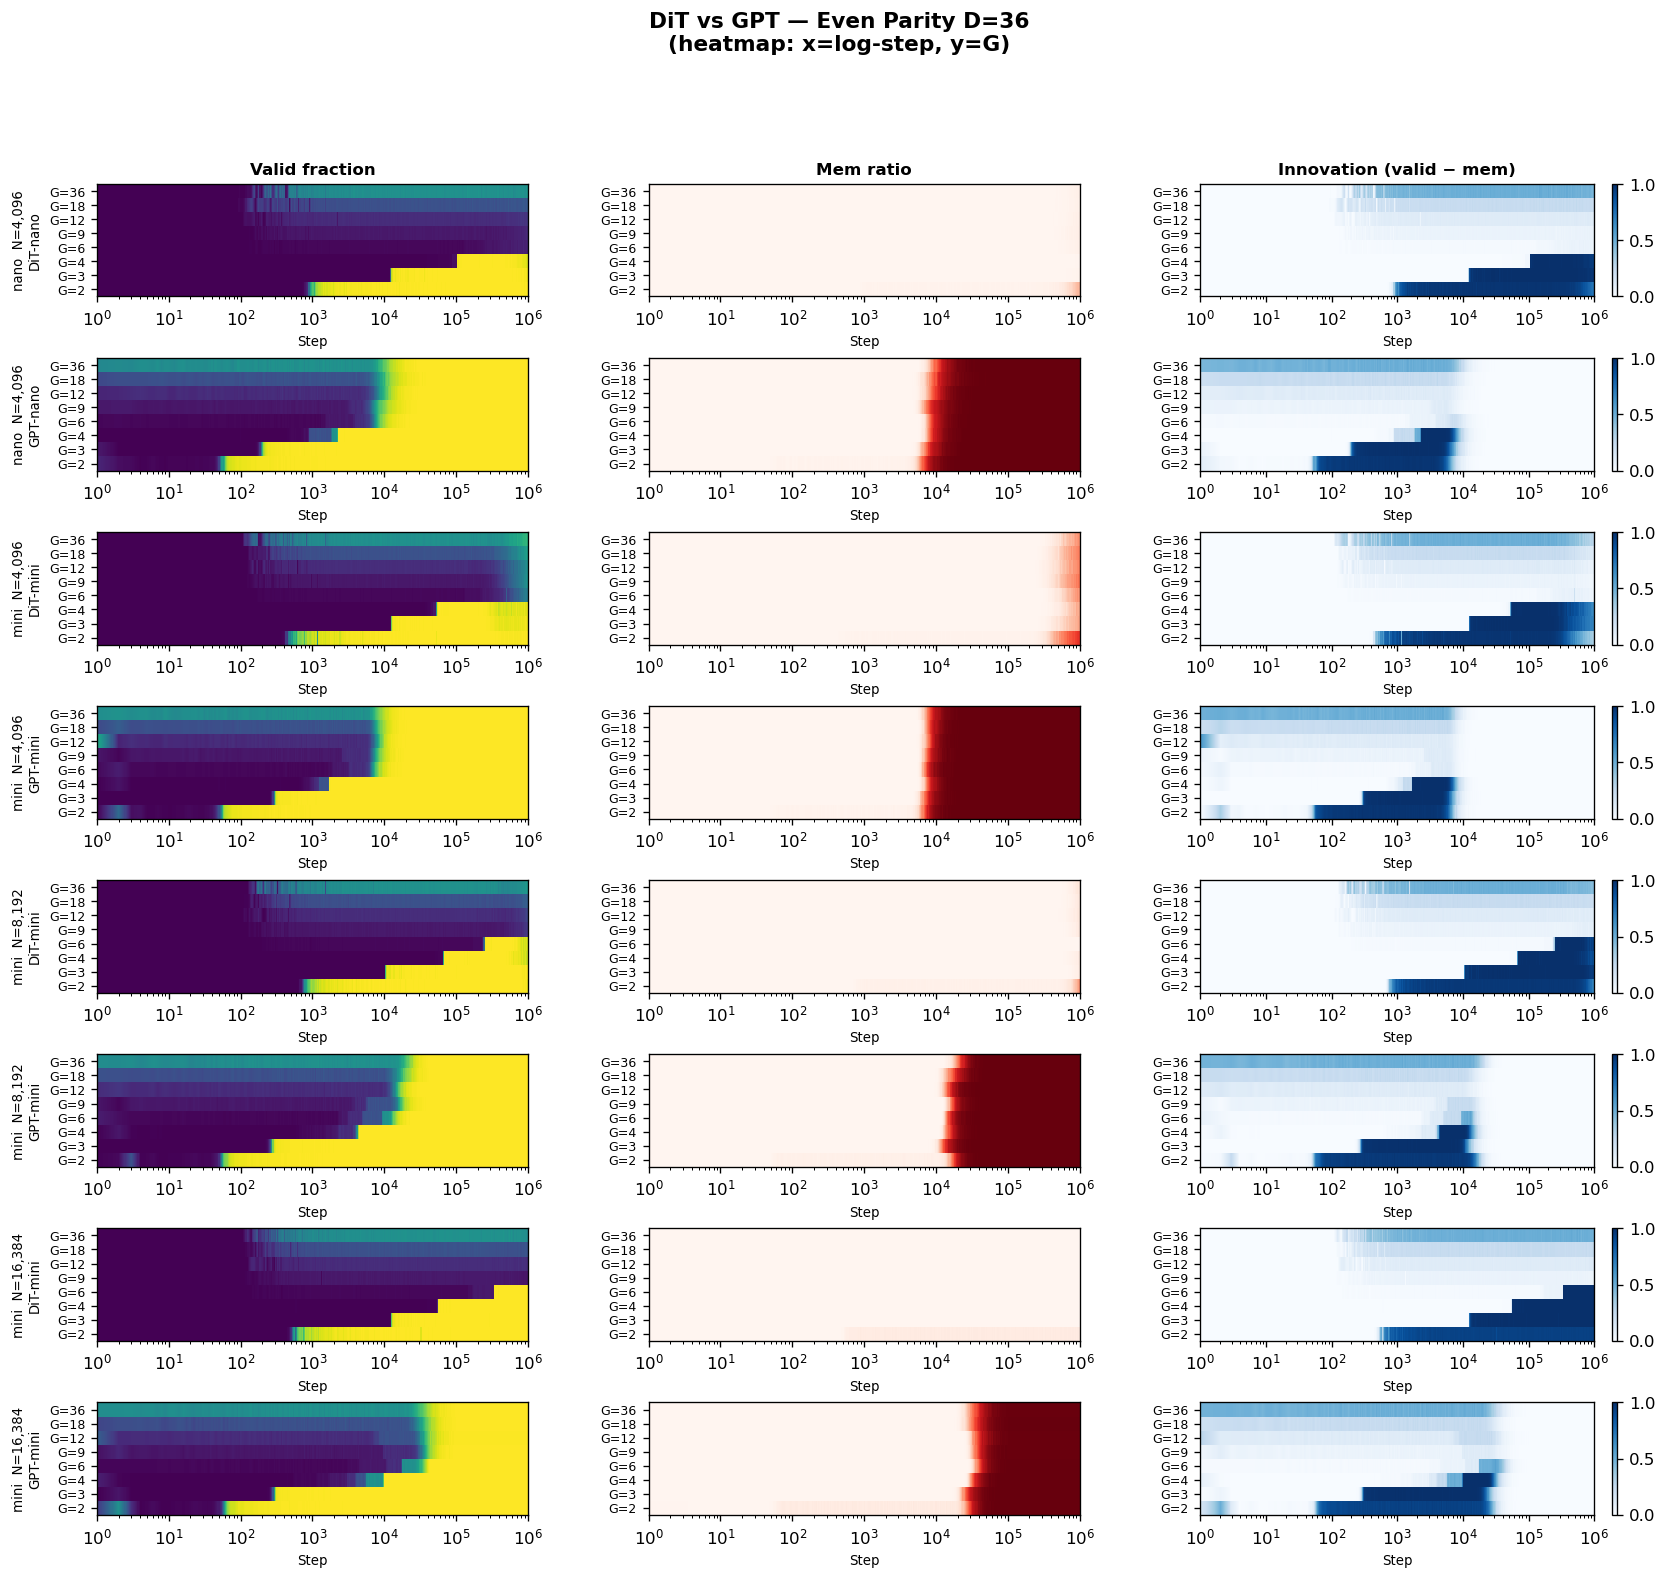

In [11]:
def plot_timeheatmap(compact_rows, outname="timeheatmap.png", save=True):
    STEP_GRID  = np.geomspace(1, 1_000_000, 400)
    METRICS    = ["valid", "mem", "innov"]
    MET_LABELS = ["Valid fraction", "Mem ratio", "Innovation (valid − mem)"]
    CMAPS      = ["viridis", "Reds", "Blues"]

    n_rows = len(compact_rows)
    fig, axes = plt.subplots(n_rows*2, 3,
                             figsize=(3*5.5, 1.6*n_rows*2 + 0.4*n_rows),
                             gridspec_kw={"hspace": 0.55, "wspace": 0.28})
    fig.suptitle("DiT vs GPT — Even Parity D=36\n(heatmap: x=log-step, y=G)",
                 fontsize=13, fontweight="bold")

    def interp_metric(data, metric):
        if data is None: return np.full(len(STEP_GRID), np.nan)
        xs = np.array(data["eval_steps"], dtype=float)
        if metric=="valid":   ys = np.array(data["valid_acc"])
        elif metric=="mem":   ys = np.array(data["mem_ratio"])
        else:                 ys = np.clip(np.array(data["valid_acc"])-np.array(data["mem_ratio"]),0,1)
        if len(xs)==0: return np.full(len(STEP_GRID), np.nan)
        out = np.interp(STEP_GRID, xs, ys, left=np.nan, right=ys[-1])
        out[STEP_GRID < xs[0]] = np.nan
        return out

    for bi, row_spec in enumerate(compact_rows):
        N = row_spec["N"]
        for mi, (metric, met_label, cmap) in enumerate(zip(METRICS, MET_LABELS, CMAPS)):
            dit_mat = np.array([interp_metric(load_dit_parity(N, G, prefix=row_spec["dit_prefix"]), metric)
                                for G in G_VALUES])
            gpt_mat = np.array([interp_metric(load_gpt_parity(N, G, prefix=row_spec["gpt_prefix"]), metric)
                                for G in G_VALUES])
            for model_idx, (mat, model_label) in enumerate([
                    (dit_mat, row_spec.get("dit_label", "DiT")),
                    (gpt_mat, row_spec.get("gpt_label", "GPT"))]):
                ax = axes[bi*2 + model_idx, mi]
                im = ax.pcolormesh(STEP_GRID, np.arange(len(G_VALUES)),
                                   mat, cmap=cmap, vmin=0, vmax=1, shading="nearest")
                ax.set_xscale("log")
                ax.set_xlim(STEP_GRID[0], STEP_GRID[-1])
                ax.set_yticks(np.arange(len(G_VALUES)))
                ax.set_yticklabels([f"G={G}" for G in G_VALUES], fontsize=7.5)
                ax.set_xlabel("Step", fontsize=8)
                if mi == 2: plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                if mi == 0:
                    ax.set_ylabel(f"{row_spec.get('row_label',f'N={N:,}')}\n{model_label}",
                                  fontsize=8, labelpad=4)
                if bi == 0 and model_idx == 0:
                    ax.set_title(met_label, fontsize=10, fontweight="bold")
    if save and SAVE_FIGS:
        out = os.path.join(OUTDIR, outname)
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.savefig(out.replace('.png','.pdf'), bbox_inches="tight")
        print(f"Saved → {out}")
    plt.show()

plot_timeheatmap(COMPACT_ROWS)